# Figure 8: Out-of-Distribution Risk Panels

This notebook consumes OOD JSON files generated by `scripts/reproduce_eval.sh`. Each panel keeps the training checkpoint fixed and plots risk as the test p-flip distribution changes.


In [19]:
# Shared imports and Matplotlib style defaults for all Fig. 8 OOD panels.
import json
import pathlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams
import matplotlib as mpl
mpl.rcParams['axes.linewidth'] = 1.3


## Fig. 8a: CLIP OOD Risk

Loads `clip-ood.json`, where CLIP checkpoints trained at p=0.20 are evaluated across shifted test p values.


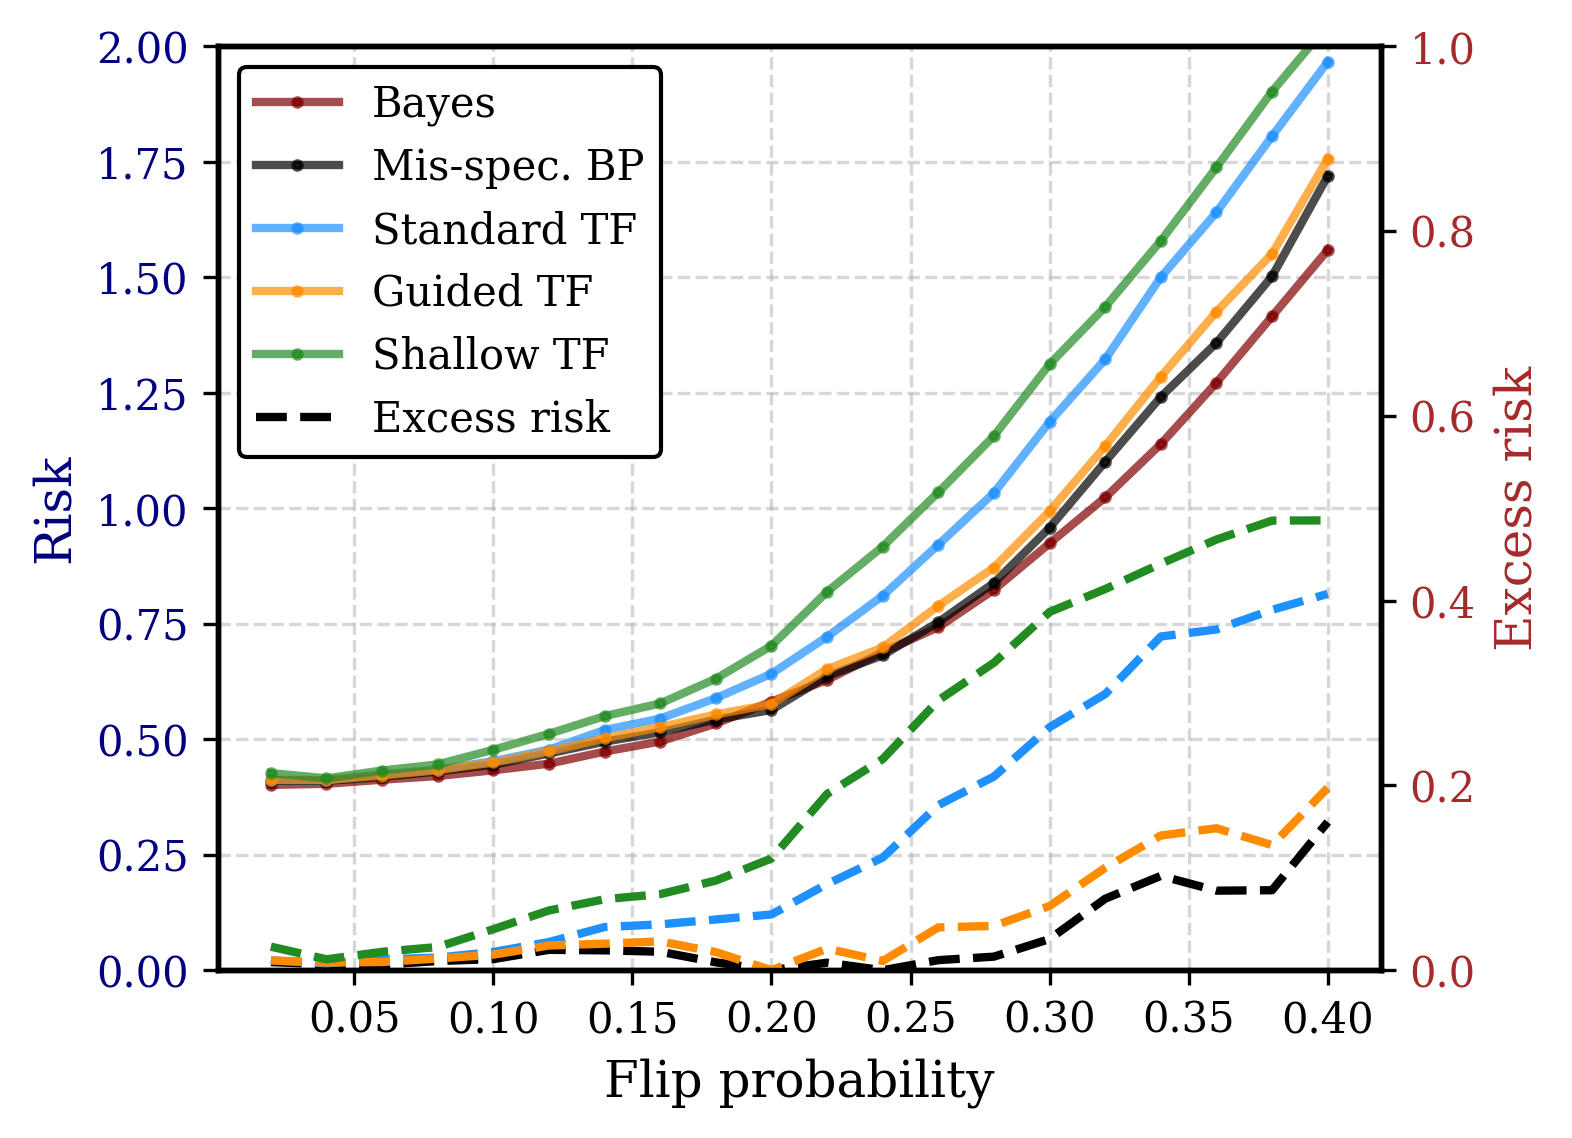

In [20]:
# Load CLIP OOD data and render Fig. 8a.

with open("./data/ghm-data/clip-ood.json", "r") as f:
    data_dict = json.load(f)
fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Mis-spec. BP": "black",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 2)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,1)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black")
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig8-a-CLIP-ood.pdf", format="pdf", dpi=300, bbox_inches="tight")


## Fig. 8b: Zero-Shot OOD Risk

Loads `zsc-ood.json`, which measures zero-shot classification under shifted test p values.


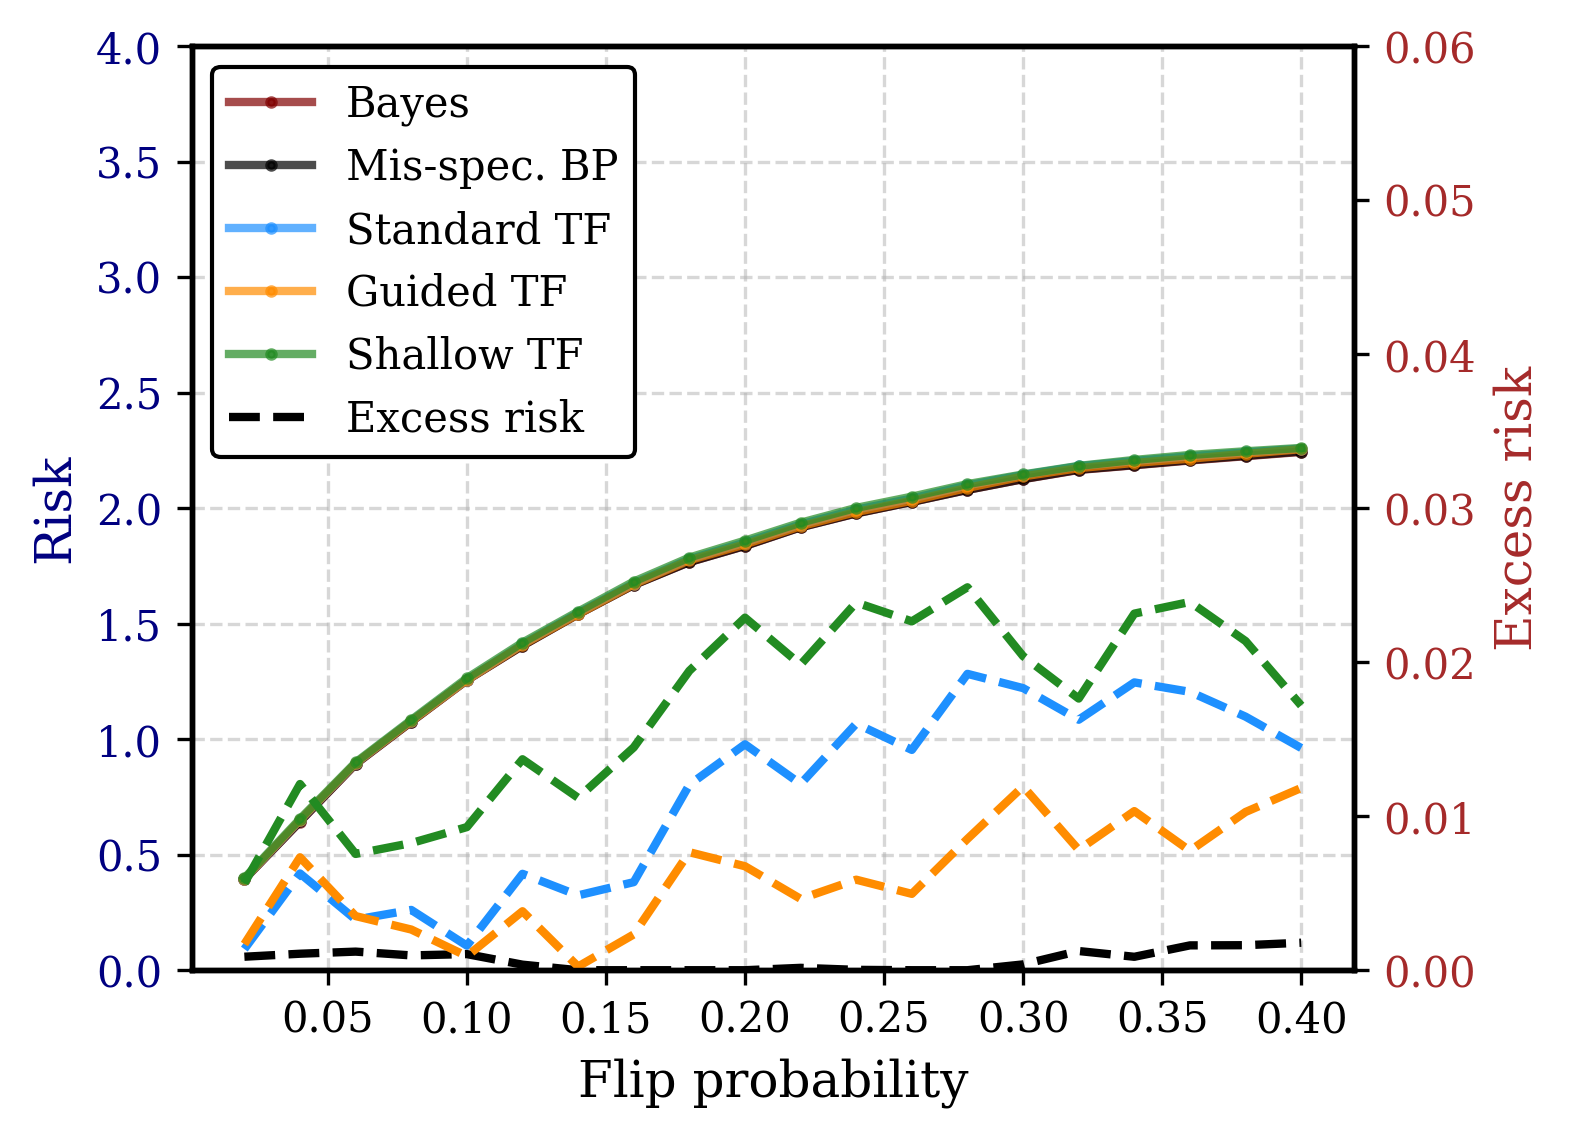

In [9]:
# Load zero-shot OOD data and render Fig. 8b.
with open("./data/ghm-data/zsc-ood.json", "r") as f:
    data_dict = json.load(f)

fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Mis-spec. BP": "black",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 4)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,0.06)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black")
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig8-b-ZSC-ood.pdf", format="pdf", dpi=300, bbox_inches="tight")


## Fig. 8c: Conditional Denoising OOD Risk

Loads `cdm-ood.json`, where CDM checkpoints are evaluated with shifted image-tree p values.


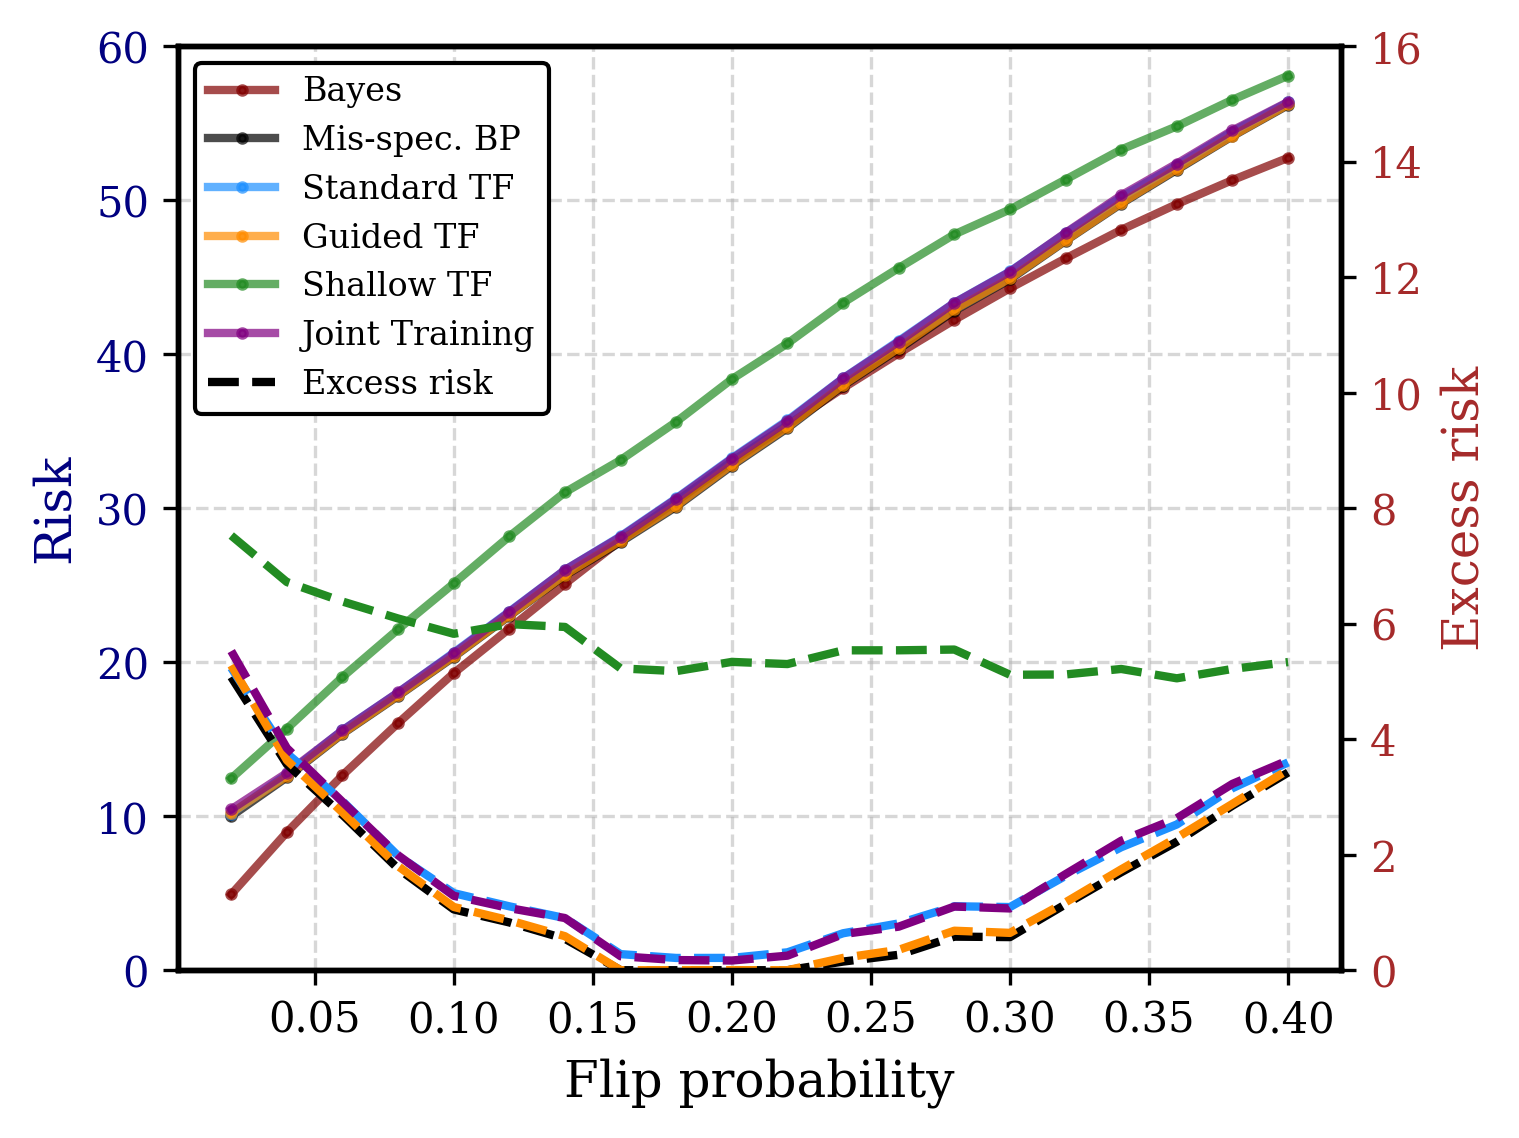

In [12]:
# Load conditional denoising OOD data and render Fig. 8c.
with open("./data/ghm-data/cdm-ood.json", "r") as f:
    data_dict = json.load(f)

fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Mis-spec. BP": "black",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
    "Joint Training": "purple",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 60)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,16)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black",fontsize=8)
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig8-c-CDM-ood.pdf", format="pdf", dpi=300, bbox_inches="tight")


## Fig. 8d: Next-Word-Prediction OOD Risk

Loads `vlm-ood.json`, where VLM checkpoints are evaluated with shifted text-tree p values.


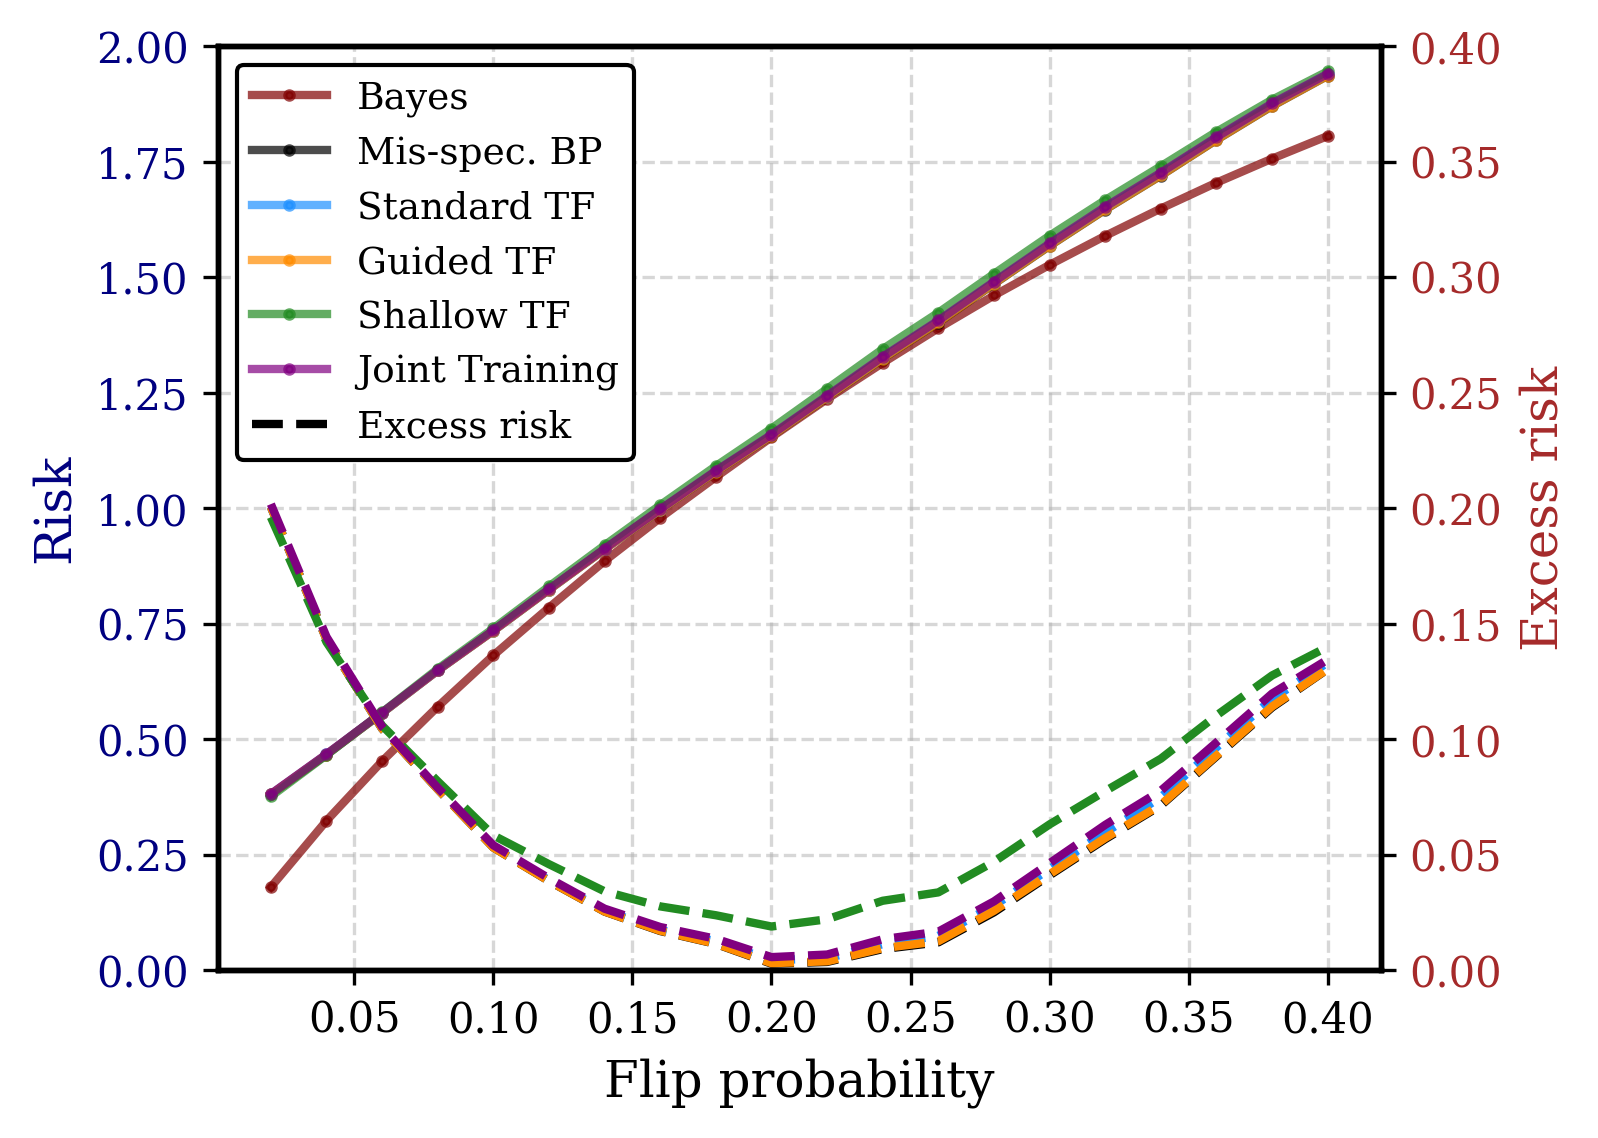

In [18]:
# Load next-word-prediction OOD data and render Fig. 8d.
with open("./data/ghm-data/vlm-ood.json", "r") as f:
    data_dict = json.load(f)

fig, ax1 = plt.subplots(figsize=(5, 4),dpi=300)

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
})
colors = {
    "Bayes": "maroon",
    "Mis-spec. BP": "black",
    "Standard TF": "dodgerblue",
    "Guided TF": "darkorange",
    "Shallow TF": "forestgreen",
    "Joint Training": "purple",
}

p_flip = np.array(data_dict["p_flip"])/100
run_types = list(colors.keys())
for model_type in run_types:
    ax1.plot(p_flip, data_dict[model_type], label=model_type, color=colors[model_type], linewidth=2, marker="o", markersize=2, alpha=0.7)
ax1.set_xlabel("Flip probability", fontsize=12)
ax1.set_ylabel(r"Risk", color="navy", fontsize=12)
ax1.tick_params(axis="y", labelcolor="navy")
ax1.grid(True, ls="--", alpha=0.5)
ax1.set_ylim(0, 2)
# ax1.set_xlim(0, 0.4)

ax2 = ax1.twinx()
for model_type in run_types[1:]:
    y_model = np.array(data_dict[model_type])
    y_bayes = np.array(data_dict["Bayes"])
    ax2.plot(p_flip, np.maximum(0, y_model - y_bayes), label="_nolegend_", color=colors[model_type], linestyle="--", linewidth=2)


# Right-axis formatting
ax2.set_ylabel(r"Excess risk", color="brown", fontsize=12)
ax2.tick_params(axis="y", labelcolor="brown")
lines_labels = [ax1.get_lines()[i] for i in range(len(colors))]
labels = list(colors.keys())
extra_line = plt.Line2D([], [], color="black", ls="--", lw=2, label="Excess risk")
lines_labels.append(extra_line)
labels.append("Excess risk")
ax2.set_ylim(0,0.4)
# ax2.set_xlim(0, 0.4)
legend = ax1.legend(lines_labels, labels, loc="upper left",
                    frameon=True, fancybox=True, framealpha=1, facecolor="white", edgecolor="black",fontsize=9)
legend.get_frame().set_linewidth(1.0)
plt.savefig("./output/Fig8-d-VLM-ood.pdf", format="pdf", dpi=300)
